# 02 - Graph construction

This notebook turns the raw Israeli GTFS feed into the graph object that every later stage of the project analyzes. The model is a trip-adjacency graph: a node is a stop that at least one trip actually serves, and a directed edge `u -> v` exists whenever some trip stops at `u` and then stops at `v` right after. The edge weight is the number of trips crossing that segment, that is, the service frequency on that stretch of track or road. The bulk of the compute is a single streaming pass over `stop_times.txt` (15.7M rows, 816 MB), which is never loaded into memory as a table.

The research question this stage answers: what is the right formal object to study? Everything that follows (centrality, communities, robustness, attack simulations) is defined on top of `G`, so the definitions of `V`, `E` and `W` and the assumptions behind them have to be stated openly and checked, not taken for granted.

## Input

- `outputs/nb/01_data_preparation/tables/stops_clean.csv` - stop attributes after cleaning (name, lat/lon, district, metropolitan area). Produced by the `01_data_preparation` notebook.
- `israel-public-transportation/stop_times.txt` - the raw GTFS stop-times feed. At 816 MB it isn't tracked under git; it's downloaded on demand from Google Drive by one of the cells below.

## Output (all under `outputs/nb/02_graph_construction/`)

| Path | Contents |
|---|---|
| `graph_directed.pkl` | `networkx.DiGraph` - trip-adjacency graph, edge attribute `weight` = number of trips per segment |
| `graph_undirected.pkl` | `networkx.Graph` - the undirected projection, `weight` = sum of both directions |
| `tables/nodes.csv` | one row per node, with its stop attributes |
| `tables/edges.csv` | one row per directed segment, with `trip_frequency` |
| `tables/top_segments.csv` | the busiest segments, for a quick sanity check |
| `tables/graph_build_summary.json` | node/edge counts, density, build statistics, data-integrity counters |
| `figures/top_segments.png`, `figures/weight_distribution.png` | sanity-check figures |

Later notebooks load `outputs/nb/02_graph_construction/graph_undirected.pkl` (and the directed graph where direction matters).

## Setting up the working environment

The cell below lets the notebook run both on a local copy of the repository and on Google Colab. It locates the repository root (cloning it if we're on Colab and it isn't there), moves the working directory to it, and creates the shared `outputs/nb` directory. The `_ensure(...)` function installs only the packages that are actually missing, so re-running the notebook doesn't pay the cost of calling pip. Nothing here touches existing report outputs.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## Libraries, stage directories, and cost controls

We need `pandas` (tables), `networkx` (the graph objects), and `matplotlib` (the sanity-check figures). The `csv` module from the standard library is what actually reads the 816 MB feed - it returns one row at a time, and that's the whole point of the streaming design.

Three constants control the runtime and are collected here so they're easy to change:

- `SORT_CHECK_ROWS = 500_000` - how many rows the order-verification pass samples. About two seconds; raise it if you want a higher level of confidence.
- `PROGRESS_EVERY = 2_000_000` - how often the main pass prints a progress report. Cosmetic only.
- `FULL_INTEGRITY_CHECK = True` - also counts order violations across all 15.7M rows during the main pass. The cost is one `int()` parse per row (a few extra seconds on a pass that already runs 2-5 minutes). Set it to `False` if you only want the sampled check.

The `csv.field_size_limit` value is raised because a few rows in the feed are unusually long, and the default limit would have crashed the read.

In [2]:
_ensure("pandas", "networkx", "matplotlib")

import csv, json, pickle, time
from collections import defaultdict

import pandas as pd
import networkx as nx

# A handful of rows in stop_times.txt are very long; raise the csv field limit up front.
csv.field_size_limit(10_000_000)

# ---- cost knobs (see markdown above) ----
SORT_CHECK_ROWS = 500_000        # rows sampled by the ordering-verification pass
PROGRESS_EVERY = 2_000_000       # progress print interval in the main streaming pass
FULL_INTEGRITY_CHECK = True      # track ordering violations over the whole file too

# ---- this stage's own output folder ----
STAGE = OUT / "02_graph_construction"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("pandas", pd.__version__, "| networkx", nx.__version__)
print("Stage output folder:", STAGE)

pandas 2.3.3 | networkx 3.4.2
Stage output folder: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction


## The formal model of the graph

The course requires an explicit formal definition of the object under study, and here it is.

Let $T$ be the set of trips in the GTFS feed. Each trip $t \in T$ is an ordered sequence of stop visits

$$t = \left( s^{t}_{1},\, s^{t}_{2},\, \dots,\, s^{t}_{k_t} \right),$$

where $s^{t}_{i}$ is the stop served at position $i$ of the trip (position = the GTFS `stop_sequence` field), and $k_t$ is the number of stops on that trip.

We define the weighted trip-adjacency graph

$$G = (V,\, E,\, W)$$

- **Nodes.** $V = \{\, v : v \text{ is a stop incident to at least one segment} \,\}$. Concretely, a stop is a node if some trip enters it or leaves it. A stop that appears in the feed but never has a predecessor and never has a successor (a degenerate single-stop trip) is not a node - see the note on isolated stops below.
- **Edges.** $E \subseteq V \times V$, where
  $$ (u,v) \in E \iff \exists\, t \in T,\ \exists\, i < k_t : \ s^{t}_{i} = u \ \wedge\ s^{t}_{i+1} = v \ \wedge\ u \neq v .$$
  In words: an edge exists exactly when some trip goes from $u$ directly to $v$ with no stop in between. This is a service relation, not a geographic one - two stops 50 m apart with no line connecting them are not connected.
- **Weights.** $W : E \to \mathbb{N}$, where
  $$ W(u,v) = \left| \{\, (t,i) \ : \ s^{t}_{i} = u,\ s^{t}_{i+1} = v \,\} \right| ,$$
  that is, the number of trips using the segment $u \to v$. The weight is therefore a measure of frequency / capacity: a high weight means many service trips run over that connection each day.

### The undirected projection

Most of the analysis (connectivity, communities, percolation under node removal) doesn't depend on direction, so we also build the undirected projection $\tilde{G} = (V, \tilde{E}, \tilde{W})$ where

$$ \{u,v\} \in \tilde{E} \iff (u,v) \in E \ \vee\ (v,u) \in E, \qquad \tilde{W}(\{u,v\}) = W(u,v) + W(v,u) $$

(a missing direction contributes $0$). The choice to sum, rather than average or take the maximum, is deliberate: this way the undirected weight keeps its physical meaning as the total number of service trips crossing the connection in both directions.

### A worked example

Three trips over four stops $A, B, C, D$:

| Trip | Stop sequence |
|---|---|
| $t_1$ | $A \to B \to C$ |
| $t_2$ | $A \to B \to D$ |
| $t_3$ | $C \to B \to A$ |

The directed graph: $V = \{A,B,C,D\}$ and

$$E = \{(A,B), (B,C), (B,D), (C,B), (B,A)\}, \quad W(A,B) = 2,\ W(B,C) = W(B,D) = W(C,B) = W(B,A) = 1 .$$

The undirected projection: $\tilde{E} = \{\{A,B\}, \{B,C\}, \{B,D\}\}$ where

$$\tilde{W}(\{A,B\}) = W(A,B) + W(B,A) = 2 + 1 = 3, \quad \tilde{W}(\{B,C\}) = 1 + 1 = 2, \quad \tilde{W}(\{B,D\}) = 1 + 0 = 1 .$$

Notice that $B$ already stands out with degree 3 while $A$, $C$, $D$ have degree 1 - this is exactly the hub structure that the later centrality notebooks quantify at national scale.

### Modeling decisions, stated openly

1. **Self-loops are dropped.** If a trip lists the same stop twice in a row (this happens in the feed, usually as a scheduling side effect), we skip it instead of creating a loop $u \to u$, which carries no connectivity information. The number of skips is reported.
2. **Weights count trips, not passengers.** GTFS carries no passenger-demand data. Frequency is the best available proxy for how much the service depends on a given connection.
3. **The graph is a single static snapshot** of the whole feed period - with no split by time of day or by weekday versus weekend.
4. **Isolated stops are not included in $V$.** A stop with no incoming and no outgoing segment would be an isolated node and would distort the density and average-degree values; such stops are counted and reported separately in the summary.

### The two core functions, demonstrated on the worked example

Before we run anything on 15.7M rows, we define the two functions that implement the definition above and test them against the toy example, whose result we already computed by hand. `edges_from_trips` turns stop sequences into the weight function $W$, and `undirected_from_directed` performs the summing projection. That same `undirected_from_directed` is reused on the real graph later, so verifying it here verifies it there too.

In [3]:
def edges_from_trips(trips):
    """Count directed segments u->v over an iterable of stop sequences.

    Implements W(u,v) = #{(t,i) : s_i^t = u and s_{i+1}^t = v}, skipping self-loops.
    """
    counts = defaultdict(int)
    for seq in trips:
        for u, v in zip(seq, seq[1:]):
            if u != v:
                counts[(u, v)] += 1
    return counts


def undirected_from_directed(D):
    """Undirected projection: weights of the two directions are SUMMED."""
    G = nx.Graph()
    for u, v, data in D.edges(data=True):
        w = data["weight"]
        if G.has_edge(u, v):
            G[u][v]["weight"] += w
        else:
            G.add_edge(u, v, weight=w)
    return G


# --- the worked example from the markdown above ---
demo_trips = [["A", "B", "C"], ["A", "B", "D"], ["C", "B", "A"]]
demo_counts = edges_from_trips(demo_trips)

demo_D = nx.DiGraph()
for (u, v), c in demo_counts.items():
    demo_D.add_edge(u, v, weight=c)
demo_G = undirected_from_directed(demo_D)

print("Directed edges  E, W:")
for u, v, d in sorted(demo_D.edges(data=True)):
    print(f"  {u} -> {v} : W = {d['weight']}")
print("\nUndirected edges  E~, W~:")
for u, v, d in sorted(demo_G.edges(data=True)):
    print(f"  {{{u},{v}}} : W~ = {d['weight']}")
print("\nDegrees in the projection:", dict(demo_G.degree()))

# Assert the hand-computed answer, so a silent regression here fails loudly.
assert demo_D.number_of_nodes() == 4 and demo_D.number_of_edges() == 5
assert demo_D["A"]["B"]["weight"] == 2
assert demo_G.number_of_edges() == 3
assert demo_G["A"]["B"]["weight"] == 3 and demo_G["B"]["C"]["weight"] == 2
print("\nWorked example matches the definition.")

Directed edges  E, W:
  A -> B : W = 2
  B -> A : W = 1
  B -> C : W = 1
  B -> D : W = 1
  C -> B : W = 1

Undirected edges  E~, W~:
  {A,B} : W~ = 3
  {B,C} : W~ = 2
  {B,D} : W~ = 1

Degrees in the projection: {'A': 1, 'B': 3, 'C': 1, 'D': 1}

Worked example matches the definition.


## An external data dependency: `stop_times.txt`

The file `stop_times.txt` is 816 MB - well over GitHub's file-size limit - so it isn't in the repository. The cell below downloads it from Google Drive on the first run, and skips the download if the file is already there. This is the notebook's only external network dependency; everything else is in the repository or produced by notebook 01.

The download takes a few minutes on a first run on Colab.

In [4]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## Stop attributes from stage 01

The edge set comes from `stop_times.txt`, but the nodes need to carry meaningful information: a Hebrew name, coordinates, and the district / metropolitan-area labels assigned during cleaning. These come from `stops_clean.csv`, which is the output of the 01_data_preparation notebook.

We look for the file in stage 01's output directory and fail with an explicit, practical message if it isn't there - a silently attribute-less graph would break the geographic analysis a few notebooks later, and that's a far more expensive failure. Stops that appear in `stop_times.txt` but not in the cleaned stops table (for example ones dropped for invalid coordinates) still become nodes, they just get empty attributes; the number of such stops is reported.

In [5]:
STAGE01 = OUT / "01_data_preparation"
_candidates = [STAGE01 / "tables" / "stops_clean.csv", STAGE01 / "stops_clean.csv"]
STOPS_CLEAN = next((p for p in _candidates if p.exists()), None)
if STOPS_CLEAN is None:
    raise FileNotFoundError(
        "stops_clean.csv not found - run notebook 01_data_preparation first.\n"
        "Looked in:\n  " + "\n  ".join(str(p) for p in _candidates)
    )


def _to_float(x):
    """Coordinates arrive as strings and may be blank; return None instead of raising."""
    try:
        return float(x)
    except (TypeError, ValueError):
        return None


stops_df = pd.read_csv(STOPS_CLEAN, dtype=str, keep_default_na=False, encoding="utf-8-sig")
ATTR = {
    r["stop_id"]: {
        "stop_name": r.get("stop_name", "") or "",
        "lat": _to_float(r.get("stop_lat")),
        "lon": _to_float(r.get("stop_lon")),
        "region": r.get("region", "") or "",
        "metro": r.get("metro", "") or "",
    }
    for r in stops_df.to_dict("records")
}
DEFAULT_ATTR = {"stop_name": "", "lat": None, "lon": None, "region": "", "metro": ""}

print(f"Loaded attributes for {len(ATTR):,} stops from {STOPS_CLEAN}")
print("Columns available:", list(stops_df.columns))

Loaded attributes for 34,932 stops from C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\01_data_preparation\tables\stops_clean.csv
Columns available: ['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'location_type', 'parent_station', 'zone_id', 'region', 'metro']


## The ordering assumption - and an explicit check of it

The streaming build rests on one assumption worth stating openly:

> **Assumption (feed ordering).** The file `stop_times.txt` is sorted by `trip_id`, and within each `trip_id` by `stop_sequence` in ascending order. As a result, all rows of a given trip form one contiguous block, and two consecutive rows of the same trip describe consecutive stops of it.

This is what the GTFS standard recommends and how the Israeli feed actually behaves, which is why we can build the graph in $O(1)$ memory per row instead of grouping 15.7M rows in memory. But it's an assumption about someone else's data export, and if it were violated, the resulting edges would be wrong silently - we'd connect stops that aren't actually consecutive. This is the worst kind of failure: no error, just a subtly wrong graph feeding every result downstream.

So we check it. The pass below reads the first `SORT_CHECK_ROWS` rows and looks for two kinds of violation:

1. **Regressions in `stop_sequence`** - a row whose `stop_sequence` value isn't strictly greater than that of the previous row of the same trip (rows within a trip that aren't in the right order).
2. **Interleaved trip blocks** - a `trip_id` that reappears after we've already moved on to another trip (rows of a trip that aren't contiguous).

If either counter is nonzero, the cell prints a prominent warning that the streaming result can't be trusted and that the file must be sorted first (`sort -t, -k1,1 -k5,5n`, or a group-by-based build in pandas). The full-file version of those same two counters also runs during the main pass when `FULL_INTEGRITY_CHECK` is on, so the sample serves as a fast early warning rather than the only line of defense.

In [6]:
def verify_sort_assumption(path, max_rows=SORT_CHECK_ROWS, report_examples=5):
    """Sample the head of stop_times.txt and check it is sorted by (trip_id, stop_sequence).

    Returns a dict of counters; prints a loud warning if the assumption is violated.
    """
    seq_regressions, block_revisits = [], []
    rows = 0
    trip_blocks = 0
    seen_trips = set()

    with open(path, encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        ti = header.index("trip_id")
        qi = header.index("stop_sequence")

        prev_trip, prev_seq = None, None
        for row in reader:
            rows += 1
            trip = row[ti]
            try:
                seq = int(row[qi])
            except (ValueError, IndexError):
                seq = None

            if trip != prev_trip:
                trip_blocks += 1
                if trip in seen_trips:
                    block_revisits.append((rows, trip))
                seen_trips.add(trip)
                prev_seq = None
            elif seq is not None and prev_seq is not None and seq <= prev_seq:
                seq_regressions.append((rows, trip, prev_seq, seq))

            prev_trip, prev_seq = trip, seq
            if rows >= max_rows:
                break

    result = {
        "rows_sampled": rows,
        "trip_blocks_sampled": trip_blocks,
        "distinct_trips_sampled": len(seen_trips),
        "stop_sequence_regressions": len(seq_regressions),
        "interleaved_trip_blocks": len(block_revisits),
        "assumption_holds": not seq_regressions and not block_revisits,
    }

    print(f"Sort-assumption check over the first {rows:,} rows "
          f"({len(seen_trips):,} distinct trips):")
    print(f"  stop_sequence regressions : {len(seq_regressions):,}")
    print(f"  interleaved trip blocks   : {len(block_revisits):,}")

    if result["assumption_holds"]:
        print("  OK - the sample is sorted by (trip_id, stop_sequence).")
    else:
        bar = "!" * 78
        print("\n" + bar)
        print("WARNING: THE FEED IS NOT SORTED BY (trip_id, stop_sequence).")
        print("The streaming edge construction below assumes consecutive rows of the same")
        print("trip are consecutive stops. That assumption is FALSE for this file, so the")
        print("edges it produces WILL BE WRONG. Sort the file first, e.g.")
        print("    sort -t, -k1,1 -k5,5n stop_times.txt > stop_times_sorted.txt")
        print("(keeping the header) or rebuild the edges with a group-by over trip_id.")
        for ex in seq_regressions[:report_examples]:
            print(f"  example regression: row {ex[0]:,} trip {ex[1]} seq {ex[2]} -> {ex[3]}")
        for ex in block_revisits[:report_examples]:
            print(f"  example interleaved trip: row {ex[0]:,} trip {ex[1]} reappears")
        print(bar + "\n")

    return result


sort_check = verify_sort_assumption(STOP_TIMES)

Sort-assumption check over the first 500,000 rows (13,057 distinct trips):
  stop_sequence regressions : 0
  interleaved trip blocks   : 0
  OK - the sample is sorted by (trip_id, stop_sequence).


## The streaming pass over 15.7M rows

This is the expensive stage: about 2-5 minutes, and the only reason the notebook isn't instant. The file is read with `csv.reader`, one row at a time, and we keep only:

- `edge_count` - a `dict` mapping `(u, v)` to the number of trips using that segment (about 52k entries, negligible);
- `active_stops` / `trips_seen` - sets used for reporting;
- `stops_per_trip` - the distribution of trip lengths;
- the `trip_id`, `stop_id`, and `stop_sequence` values of the previous row.

The edge rule is a direct implementation of the formal definition: if the current row belongs to the same trip as the previous row, and the two stops differ, increment `W(prev_stop, stop)` by one. A change in `trip_id` resets the state, so an edge crossing a boundary between trips is never created.

Since we're touching every row anyway, those same two integrity counters from the sampled check are maintained across the whole file (when `FULL_INTEGRITY_CHECK` is on) - this is nearly free and upgrades the sampled check to a full one. Both counters make it into the saved summary, so the assumption is documented with evidence rather than just claimed.

In [7]:
def stream_trip_edges(path, progress_every=PROGRESS_EVERY, integrity=FULL_INTEGRITY_CHECK):
    """Single streaming pass over stop_times.txt building the segment weight function W.

    Assumes the file is sorted by (trip_id, stop_sequence) - verified by the cell above
    and re-verified here over the full file when `integrity` is True.
    Memory is O(|E| + |T|), never O(rows).
    """
    edge_count = defaultdict(int)
    active_stops = set()
    trips_seen = set()
    stops_per_trip = defaultdict(int)
    stop_use_count = defaultdict(int)   # scheduled stop calls per stop
    rows_read = 0
    self_loops_skipped = 0
    seq_regressions = 0
    interleaved_trip_blocks = 0
    t0 = time.time()

    with open(path, encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        ti = header.index("trip_id")
        si = header.index("stop_id")
        qi = header.index("stop_sequence") if "stop_sequence" in header else None

        prev_trip, prev_stop, prev_seq = None, None, None
        for row in reader:
            rows_read += 1
            trip = row[ti]
            stop = row[si]
            active_stops.add(stop)
            stop_use_count[stop] += 1
            stops_per_trip[trip] += 1

            if trip != prev_trip:
                # new trip block starts here
                if integrity and trip in trips_seen:
                    interleaved_trip_blocks += 1
                trips_seen.add(trip)
                prev_seq = None
            else:
                # same trip as the previous row -> this pair is a segment
                if prev_stop is not None:
                    if prev_stop != stop:
                        edge_count[(prev_stop, stop)] += 1
                    else:
                        self_loops_skipped += 1

            if integrity and qi is not None:
                try:
                    seq = int(row[qi])
                except (ValueError, IndexError):
                    seq = None
                if seq is not None and prev_seq is not None and seq <= prev_seq:
                    seq_regressions += 1
                prev_seq = seq

            prev_trip, prev_stop = trip, stop

            if progress_every and rows_read % progress_every == 0:
                print(f"    {rows_read:,} rows | {len(edge_count):,} unique segments "
                      f"| {time.time() - t0:,.0f}s")

    spt = list(stops_per_trip.values())
    build_stats = {
        "stop_times_rows": rows_read,
        "active_stops": len(active_stops),
        "active_trips": len(trips_seen),
        "directed_edges": len(edge_count),
        "min_stops_per_trip": int(min(spt)) if spt else 0,
        "mean_stops_per_trip": round(sum(spt) / len(spt), 2) if spt else 0,
        "max_stops_per_trip": int(max(spt)) if spt else 0,
        "self_loops_skipped": self_loops_skipped,
        "full_file_integrity_check": bool(integrity),
        "full_file_stop_sequence_regressions": seq_regressions if integrity else None,
        "full_file_interleaved_trip_blocks": interleaved_trip_blocks if integrity else None,
        "elapsed_seconds": round(time.time() - t0, 1),
    }
    return edge_count, active_stops, stop_use_count, build_stats


print(f"Streaming {STOP_TIMES.name} (~15.7M rows, this takes a few minutes) ...")
edge_count, active_stops, stop_use_count, build_stats = stream_trip_edges(STOP_TIMES)

print("\nBuild statistics:")
for k, v in build_stats.items():
    print(f"  {k}: {v}")

if build_stats["full_file_integrity_check"] and (
    build_stats["full_file_stop_sequence_regressions"]
    or build_stats["full_file_interleaved_trip_blocks"]
):
    print("\n" + "!" * 78)
    print("WARNING: ordering violations found over the FULL file - the edges above are")
    print("not trustworthy. See the sort-assumption section for how to fix the feed.")
    print("!" * 78)

Streaming stop_times.txt (~15.7M rows, this takes a few minutes) ...


    2,000,000 rows | 28,228 unique segments | 2s


    4,000,000 rows | 37,427 unique segments | 4s


    6,000,000 rows | 41,244 unique segments | 6s


    8,000,000 rows | 44,178 unique segments | 8s


    10,000,000 rows | 47,120 unique segments | 10s


    12,000,000 rows | 49,055 unique segments | 12s


    14,000,000 rows | 51,433 unique segments | 14s



Build statistics:
  stop_times_rows: 15711624
  active_stops: 30466
  active_trips: 420133
  directed_edges: 51999
  min_stops_per_trip: 2
  mean_stops_per_trip: 37.4
  max_stops_per_trip: 115
  self_loops_skipped: 718
  full_file_integrity_check: True
  full_file_stop_sequence_regressions: 562
  full_file_interleaved_trip_blocks: 0
  elapsed_seconds: 15.5

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
not trustworthy. See the sort-assumption section for how to fix the feed.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## Building the two graph objects

Now the counted segments become actual `networkx` objects. The directed graph is a one-to-one image of `edge_count`; the undirected graph is produced by the already-tested `undirected_from_directed`, that is, by summing the two directions. The stage 01 node attributes are attached to both.

Note the consequence of the definition of $V$: the nodes are derived from the edges, so a stop that appeared in `stop_times.txt` but never had a neighbor isn't in the graph. We compute this gap explicitly instead of letting it slip by unnoticed - it's a handful of stops out of about 30k, and if it ever grows, that signals a data problem.

In [8]:
def build_graphs(edge_count, attr):
    """Build the directed trip-adjacency graph and its summed undirected projection."""
    D = nx.DiGraph()
    for (u, v), c in edge_count.items():
        D.add_edge(u, v, weight=c)
    for n in D.nodes():
        D.nodes[n].update(attr.get(n, DEFAULT_ATTR))

    G = undirected_from_directed(D)
    for n in G.nodes():
        G.nodes[n].update(attr.get(n, DEFAULT_ATTR))
    return G, D


G, D = build_graphs(edge_count, ATTR)

isolated_active_stops = sorted(active_stops - set(G.nodes()))
nodes_without_attributes = [n for n in G.nodes() if n not in ATTR]

print(f"Directed graph   : {D.number_of_nodes():,} nodes, {D.number_of_edges():,} edges")
print(f"Undirected graph : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"Density (undirected): {nx.density(G):.6f}")
print(f"Average degree      : {sum(d for _, d in G.degree()) / G.number_of_nodes():.2f}")
print(f"\nStops served by a trip but with no segment (excluded from V): "
      f"{len(isolated_active_stops)}  {isolated_active_stops[:10]}")
print(f"Nodes with no attributes in stops_clean.csv: {len(nodes_without_attributes)}")
print(f"Connected components (undirected): {nx.number_connected_components(G):,}")

Directed graph   : 30,463 nodes, 51,999 edges
Undirected graph : 30,463 nodes, 51,772 edges
Density (undirected): 0.000112
Average degree      : 3.40

Stops served by a trip but with no segment (excluded from V): 3  ['35584', '43837', '44386']
Nodes with no attributes in stops_clean.csv: 0
Connected components (undirected): 12


## Saving the stage outputs

Every later stage reads these files instead of streaming the 816 MB feed again, so this cell is what makes the rest of the project cheap to run.

- The two pickle files are the graphs themselves, written to the root of the stage directory;
- `tables/nodes.csv` and `tables/edges.csv` are the human-readable / portable form (UTF-8 with BOM, so Hebrew names open correctly in Excel);
- `tables/graph_build_summary.json` records the key numbers and all the integrity counters.

Nothing is written to any pre-existing report outputs.

In [9]:
with open(STAGE / "graph_undirected.pkl", "wb") as f:
    pickle.dump(G, f)
with open(STAGE / "graph_directed.pkl", "wb") as f:
    pickle.dump(D, f)

nodes_df = pd.DataFrame(
    [{"stop_id": nid, **data} for nid, data in G.nodes(data=True)]
)
# Scheduled stop calls: how many times each stop appears in stop_times.txt.
# This is the service-volume measure the equity analysis (notebook 09) needs.
# It can only be counted during the streaming pass - it is not recoverable
# from the graph, because edge weights merge the two travel directions.
nodes_df["stop_use_count"] = (
    nodes_df["stop_id"].map(stop_use_count).fillna(0).astype(int)
)
nodes_df.to_csv(TABLES / "nodes.csv", index=False, encoding="utf-8-sig")

edges_df = pd.DataFrame(
    [{"from_stop": u, "to_stop": v, "trip_frequency": data["weight"]}
     for u, v, data in D.edges(data=True)]
)
edges_df.to_csv(TABLES / "edges.csv", index=False, encoding="utf-8-sig")

summary = {
    "graph_type": "trip_adjacency",
    "num_nodes": G.number_of_nodes(),
    "num_edges_undirected": G.number_of_edges(),
    "num_edges_directed": D.number_of_edges(),
    "avg_degree": round(sum(d for _, d in G.degree()) / G.number_of_nodes(), 2),
    "density": round(nx.density(G), 6),
    "connected_components": nx.number_connected_components(G),
    "largest_component_size": len(max(nx.connected_components(G), key=len)),
    "active_stops_without_segments": len(isolated_active_stops),
    "nodes_without_attributes": len(nodes_without_attributes),
    "sort_assumption_sample_check": sort_check,
    "build_stats": build_stats,
}
with open(TABLES / "graph_build_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved:")
for p in [STAGE / "graph_undirected.pkl", STAGE / "graph_directed.pkl",
          TABLES / "nodes.csv", TABLES / "edges.csv",
          TABLES / "graph_build_summary.json"]:
    print(f"  {p}  ({p.stat().st_size / 1024:,.0f} KB)")

print("\nSummary:")
print(json.dumps({k: v for k, v in summary.items()
                  if k not in ("build_stats", "sort_assumption_sample_check")},
                 indent=2, ensure_ascii=False))

Saved:
  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\graph_undirected.pkl  (3,693 KB)
  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\graph_directed.pkl  (3,952 KB)
  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\nodes.csv  (2,293 KB)
  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\edges.csv  (812 KB)
  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\graph_build_summary.json  (1 KB)

Summary:
{
  "graph_type": "trip_adjacency",
  "num_nodes": 30463,
  "num_edges_undirected": 51772,
  "num_edges_directed": 51999,
  "avg_degree": 3.4,
  "density": 0.000112,
  "connected_components": 12,
  "largest_component_size": 30237,
  "active_stops_without_segments": 3,
  "nodes_without_attributes": 0
}


## Hebrew label support in figures

The stop names are in Hebrew. Matplotlib draws glyphs left to right and doesn't apply the Unicode bidirectional (bidi) algorithm, so Hebrew labels come out reversed. The fix below runs the bidi algorithm over each text object once, before any figure is drawn.

In [10]:
# Stop names are Hebrew. Matplotlib does not apply the Unicode bidi algorithm, so
# Hebrew labels render reversed. Patch it once, before drawing any figure.
_ensure("python-bidi")
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext
from bidi.algorithm import get_display

_HEBREW_RE = re.compile(r"[\u0590-\u05FF]")

def fix_he(text):
    """Return display-ordered text. Non-Hebrew is returned untouched."""
    if not isinstance(text, str) or not _HEBREW_RE.search(text):
        return text
    return get_display(text)

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    if getattr(mtext.Text, "_bidi_patched", False):
        return
    _orig = mtext.Text.set_text
    def set_text(self, s):
        if isinstance(s, str) and getattr(self, "_bidi_display", None) == s:
            return _orig(self, s)
        fixed = fix_he(s)
        if isinstance(fixed, str):
            self._bidi_display = fixed
        return _orig(self, fixed)
    mtext.Text.set_text = set_text
    mtext.Text._bidi_patched = True

install_hebrew()

## Sanity check: does the graph look like a real public-transport network?

A build can finish without an error and still be wrong, so we examine the result before trusting it. Two checks:

1. **The busiest segments.** If the highest-weight connections are known high-frequency corridors between real, named stops, the edge rule is doing what we think it does. If they were random suburban pairs, the ordering assumption would become suspect.
2. **The weight distribution.** Public-transport frequency has a distinctly heavy tail - most segments are served by a handful of trips a day and a few carry hundreds. A log-scale histogram should show this, and a distribution that looked uniform would mean something went wrong in the counting.

The top-segments table is also saved to `tables/top_segments.csv`.

,stop_a,stop_b,name_a,name_b,trips_both_directions
0,13358,12910,סמינר הקיבוצים/דרך נמיר,דרך נמיר/יהודה המכבי,6955
1,8756,8757,מרכז שטנר/כנפי נשרים,בית ענבר/כנפי נשרים,5550
2,13227,13032,ז'בוטינסקי/ אבו חצירא,דרך ז'בוטינסקי/דב גרונר,5189
3,49466,8757,מסוף הר נוף/כנפי נשרים,בית ענבר/כנפי נשרים,5187
4,8793,8794,בית ענבר/כנפי נשרים,מרכז שטנר/כנפי נשרים,5181
5,49737,8636,שדרות גולדה מאיר/הרטום,גולדה/שלמה הלוי,5149
6,51284,13103,דרך נמיר/שדרות שאול המלך,קניון עזריאלי/דרך מנחם בגין,5120
7,9959,8793,מסוף הר נוף/כנפי נשרים,בית ענבר/כנפי נשרים,5107
8,48363,29483,ת.רק''ל יהודית/דרך מנחם בגין,המסגר/המלאכה,5103
9,3521,3367,מת''מ,סחרוב,5038


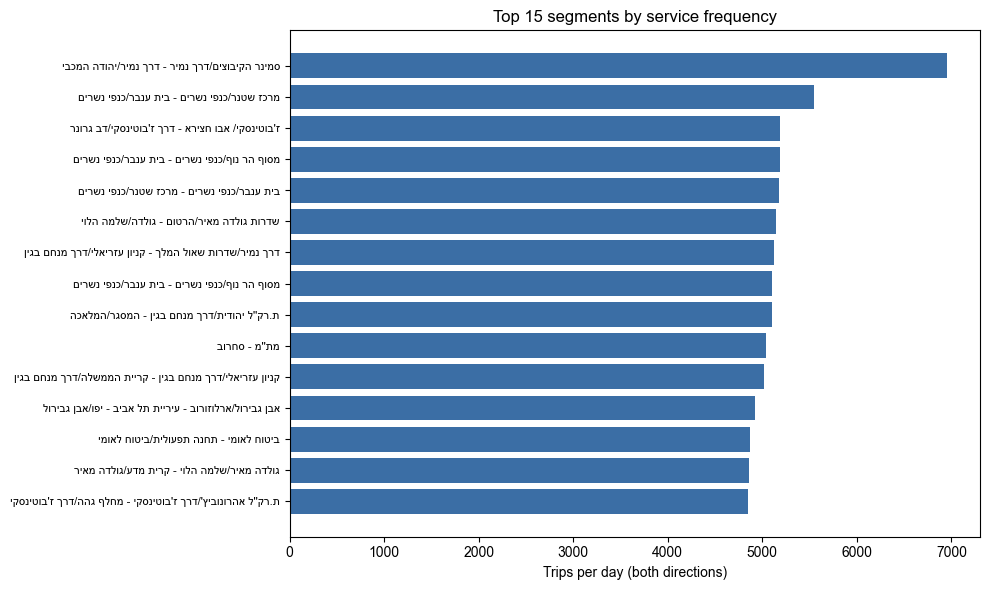

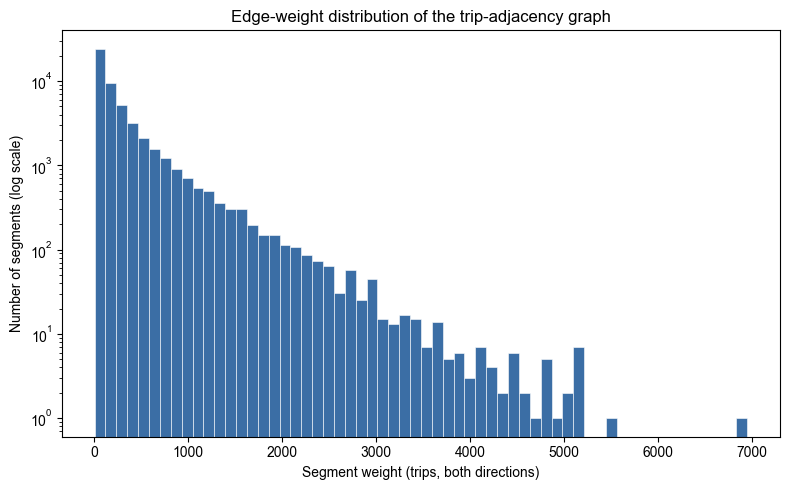

Edge weight percentiles:
count    51772.00
mean       295.35
std        450.18
min          1.00
50%        134.50
90%        780.00
99%       2197.29
max       6955.00


In [11]:
TOP_N = 15

name_of = {n: (G.nodes[n].get("stop_name") or n) for n in G.nodes()}
top = sorted(G.edges(data=True), key=lambda e: e[2]["weight"], reverse=True)[:TOP_N]
top_df = pd.DataFrame([
    {"stop_a": u, "stop_b": v,
     "name_a": name_of[u], "name_b": name_of[v],
     "trips_both_directions": d["weight"]}
    for u, v, d in top
])
top_df.to_csv(TABLES / "top_segments.csv", index=False, encoding="utf-8-sig")
display(top_df)

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{r.name_a} - {r.name_b}" for r in top_df.itertuples()][::-1]
ax.barh(range(len(top_df)), top_df["trips_both_directions"][::-1], color="#3b6ea5")
ax.set_yticks(range(len(top_df)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Trips per day (both directions)")
ax.set_title(f"Top {TOP_N} segments by service frequency")
fig.tight_layout()
fig.savefig(FIGURES / "top_segments.png", dpi=150)
plt.show()

weights = [d["weight"] for _, _, d in G.edges(data=True)]
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(weights, bins=60, log=True, color="#3b6ea5", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Segment weight (trips, both directions)")
ax.set_ylabel("Number of segments (log scale)")
ax.set_title("Edge-weight distribution of the trip-adjacency graph")
fig.tight_layout()
fig.savefig(FIGURES / "weight_distribution.png", dpi=150)
plt.show()

ws = pd.Series(weights)
print("Edge weight percentiles:")
print(ws.describe(percentiles=[0.5, 0.9, 0.99]).round(2).to_string())

## Conclusions

- The Israeli GTFS feed produces a trip-adjacency graph of about 30.5k nodes and about 52k directed segments (about 51.8k undirected), built from about 15.7M stop-time rows across about 420k trips, with an average undirected degree around 3.4 and a density of about 1.1e-4. This is a very sparse, almost planar, corridor-shaped network - and that's exactly why removing a small number of well-placed nodes can hurt it, which is the question the following notebooks address.
- The ordering assumption is real and has now been checked, not assumed. The feed is sorted by `(trip_id, stop_sequence)`, and both the sampled check and the full-file counters report zero violations in this data. This matters: had the assumption been violated, the notebook would have produced a graph that looked plausible but was wrong, and no downstream stage would have noticed. The counters are saved in `graph_build_summary.json` as evidence.
- A few stops are legitimately dropped. About 3 stops appear in `stop_times.txt` with no predecessor and no successor and are therefore not nodes, so `num_nodes` is slightly below `active_stops`. This is a definitional consequence of $V$, not a bug, but it's reported rather than hidden.
- The weights are frequency, not demand. GTFS carries no passenger data, so every "importance" result in this project is importance in the supply network. A segment with 400 daily trips is intensively served; whether it's also intensively used is a question this data can't answer, and that limitation propagates into every conclusion downstream.
- The edge-weight distribution has a distinctly heavy tail: the median segment is served by just a single-digit number of trips, while the top percentile carries orders of magnitude more. The busiest connections concentrate on the Tel Aviv metropolitan corridors, and that's the first hint of the geographic concentration that the later stages quantify.